In [1]:
import numpy as np
import matplotlib.pyplot as plt

## Create 2D synethetic data

[[0.21 3.35]
 [0.62 4.18]
 [0.53 2.76]
 [0.94 4.01]
 [1.13 4.6 ]
 [1.36 4.92]
 [1.67 3.68]
 [2.01 4.  ]
 [2.3  4.6 ]
 [2.64 6.42]
 [2.84 5.11]
 [3.24 6.23]
 [3.26 7.33]
 [3.86 7.2 ]
 [3.7  7.32]
 [4.28 7.27]
 [4.42 8.18]
 [4.75 8.87]
 [4.81 7.31]
 [5.1  9.12]]


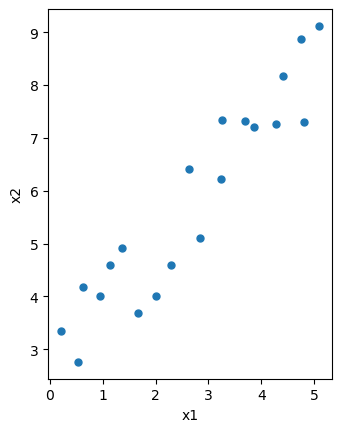

In [2]:
np.random.seed(1) # for reproducible results

N = 20
x1 = np.linspace(0,5,N) + np.random.rand(N)*0.5
x2 = 1.2 * x1 + 1.5 + np.random.rand(N)*2
x1 = np.round(x1,2)
x2 = np.round(x2,2)
X = np.c_[x1,x2]
print(X)

plt.plot(X[:,0], X[:,1],'.', markersize=10)
plt.xlabel('x1')
plt.ylabel('x2')
plt.gca().set_aspect('equal')

In [3]:
from sklearn.decomposition import PCA

model = PCA(n_components=1)
model.fit(X)

print("compare the mean values obtained from model.mean_ and those obtained manually:")
print(model.mean_)
print(np.mean(X,axis=0))

compare the mean values obtained from model.mean_ and those obtained manually:
[2.6835 5.823 ]
[2.6835 5.823 ]


#### PC, latent variable

In [4]:
u = model.components_ # dimension is L-by-D (which is 1-by-2 here)
print("the principle component u (the eigenvector associated with the largest eigenvalue):")
print(u)
print("checking the norm of u:")
print(np.linalg.norm(u)) # the norm of u is enforced to be 1
print("shape of u:", u.shape)
z = model.transform(X)
print("latent variables z:")
print(z)
print("mean value of z: ", np.mean(z))

the principle component u (the eigenvector associated with the largest eigenvalue):
[[0.62757323 0.77855754]]
checking the norm of u:
1.0
shape of u: (1, 2)
latent variables z:
[[-3.47767518]
 [-2.5741674 ]
 [-3.73620069]
 [-2.50569874]
 [-1.92711088]
 [-1.53363063]
 [-2.30449427]
 [-1.84198096]
 [-1.1928502 ]
 [ 0.43749941]
 [-0.45689631]
 [ 0.66611742]
 [ 1.53508218]
 [ 1.81041364]
 [ 1.80342882]
 [ 2.12849342]
 [ 2.92484103]
 [ 3.6691449 ]
 [ 2.49224954]
 [ 4.08343491]]
mean value of z:  -5.329070518200751e-16


In [5]:
# manually calculate the latent variables, and compare with those obtained directly
# using model.transform(X) above

X0 = np.copy(X)
mu_x = np.mean(X,axis=0)
X0 = X0 - np.outer(np.ones(N),mu_x)
# X0 = X0 - mu_x
z2 = X0 @ u.T
print(z2)

print("size of z: ", z.shape)
print(np.allclose(z2,z))

[[-3.47767518]
 [-2.5741674 ]
 [-3.73620069]
 [-2.50569874]
 [-1.92711088]
 [-1.53363063]
 [-2.30449427]
 [-1.84198096]
 [-1.1928502 ]
 [ 0.43749941]
 [-0.45689631]
 [ 0.66611742]
 [ 1.53508218]
 [ 1.81041364]
 [ 1.80342882]
 [ 2.12849342]
 [ 2.92484103]
 [ 3.6691449 ]
 [ 2.49224954]
 [ 4.08343491]]
size of z:  (20, 1)
True


#### Explained variance

In [6]:
print("explained variance: ", model.explained_variance_)
print("explained (manually calculated): ", sum(z**2)/(N-1))

explained variance:  [6.01654724]
explained (manually calculated):  [6.01654724]


In [7]:
# Performing PCA manually

S = (X0.T @ X0)/(N-1) # the covariance matrix of the mean-subtracted original data
print("Covariance matrix:")
print(S)
lb,v = np.linalg.eigh(S) # np.linalg.eigh() is optimized for symmetric matrices.

print("eigenvalues in ASCENDING order:")
print(lb) # Note: by default, the numpy package ranks eigenvalues in ascending (rather than descending) order.

print("eigenvector matrix (the feature vector) calculated manually:")
print(v)

print("eigenvector corresponding to the largest eigenvalue:")
print(v[:,-1])

print("compare to feature vector obtained using model.components_ above (note that columns are arranged differently, and signs may flip):")
print(u)

Covariance matrix:
[[2.480445   2.85035211]
 [2.85035211 3.71895895]]
eigenvalues in ASCENDING order:
[0.1828567  6.01654724]
eigenvector matrix (the feature vector) calculated manually:
[[-0.77855754  0.62757323]
 [ 0.62757323  0.77855754]]
eigenvector corresponding to the largest eigenvalue:
[0.62757323 0.77855754]
compare to feature vector obtained using model.components_ above (note that columns are arranged differently, and signs may flip):
[[0.62757323 0.77855754]]


In [8]:
# check to ensure that the total variance of the mean-subtracted original data is equal to the sum of all eigenvalues.
print(np.sum(X0**2)/(N-1))
print(np.sum(lb))

6.19940394736842
6.199403947368421


#### Reconstruction

In [9]:
Xh = model.inverse_transform(z)
# model.inverse_transform() is the built-in function for transforming data from z to x-tilde
print(Xh)

[[0.50100415 3.11542978]
 [1.06802145 3.81886257]
 [0.33876046 2.91415279]
 [1.11099054 3.87216936]
 [1.47409679 4.3226333 ]
 [1.72103447 4.62898032]
 [1.23726108 4.02881862]
 [1.52752205 4.38891184]
 [1.93489914 4.89429748]
 [2.95806292 6.16361847]
 [2.3967641  5.46727993]
 [3.10153746 6.34161074]
 [3.64687648 7.0181498 ]
 [3.81966714 7.23251118]
 [3.81528366 7.2270731 ]
 [4.0192855  7.4801546 ]
 [4.51905194 8.10015703]
 [4.98615712 8.67964041]
 [4.2475691  7.76335966]
 [5.24615445 9.00218903]]


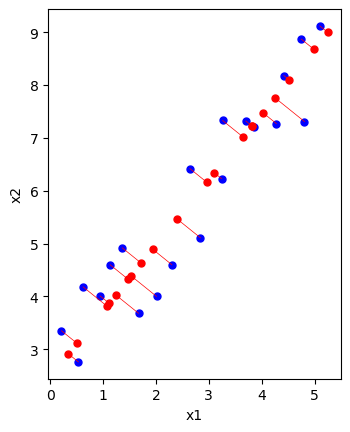

In [10]:
plt.plot(X[:,0], X[:,1],'b.', markersize=10)
plt.plot(Xh[:,0], Xh[:,1],'r.', markersize=10) # reconstructed data plotted in red

# Draw line between training example and reconstruction
for i in range(N):
    xy_22 = np.zeros((2,2))
    xy_22[0] = X[i,:]
    xy_22[1] = Xh[i,:]
    plt.plot(xy_22[:,0], xy_22[:,1], 'r-',lw=0.5) # what is being plotted here?

plt.xlabel('x1')
plt.ylabel('x2')
plt.gca().set_aspect('equal')

In [11]:
# performing reconstruction mannually

Xh2 = z @ u + np.outer(np.ones(N),mu_x)
print(np.allclose(Xh,Xh2))

True
